In [1]:
# 주요 라이브러리 import

import pandas as pd
import numpy as np
import sklearn
import scipy
import statsmodels
import mlxtend
import sys
import imblearn

print(sys.version)
for i in [pd, np, sklearn, scipy, mlxtend, statsmodels, imblearn]:
    print(i.__name__, i.__version__)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas 2.2.2
numpy 2.0.2
sklearn 1.6.1
scipy 1.16.3
mlxtend 0.23.4
statsmodels 0.14.6
imblearn 0.14.2


In [2]:
# 시각화 라이브러리 Import
import matplotlib.pyplot as plt
import seaborn as sns

- 강의 git에서 데이터셋을 다운로드합니다.

In [3]:
import os
if not os.path.isfile("books.csv"):
    !git clone https://github.com/sunkusun9/DS_prob1_2608.git
    !mv DS_prob1_2608/*.csv .
    !rm -rf DS_prob1_2608
!ls -l

Cloning into 'DS_prob1_2608'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 19 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 1.54 MiB | 3.90 MiB/s, done.
Resolving deltas: 100% (4/4), done.
total 3668
-rw-r--r-- 1 root root   42042 Aug 14 00:20 books.csv
-rw-r--r-- 1 root root 3523745 Aug 14 00:20 ratings.csv
drwxr-xr-x 1 root root    4096 Aug 10 13:26 sample_data
-rw-r--r-- 1 root root   80658 Aug 14 00:20 to_read_ans.csv
-rw-r--r-- 1 root root   13557 Aug 14 00:20 to_read_kaggle.csv
-rw-r--r-- 1 root root   79783 Aug 14 00:20 to_read_sample.csv


# 문제 개요

유명 도서 전자상거래 회사에 Junior Data Scientist 지희가 근무하고 있습니다.

이 회사의 도서 전자상거래 사이트에는 사용자가 책을 '읽을 책(to read)'으로 표시하는 기능이 있습니다.

사용자가 '읽을 책(to read)'에 남긴 내역은 양이 많지는 않지만,

사용자의 선호도를 직접 드러낸다는 점에서 순도가 높은 데이터라고 판단됩니다.

지희는 사용자의 to read에 담길 만한 도서를 예측하여,

사용자에게 도서를 추천하는 시스템을 구상하고 있습니다.

지희가 도서 추천 프로젝트를 성공적으로 이끌 수 있도록 아래 미션들을 수행해 봅니다.

## 데이터셋 구성 요약

<div style="display: flex; flex-wrap: wrap; gap: 50px;">

<!-- books.csv -->
<div style="flex: 1; min-width: 300px;">

- **books.csv**

  도서 정보

| 변수명 | 설명 | 타입 |
|:--|:--|:--|
| `book_id` | 도서 번호 | 정수형 |
| `authors` | 저자 | 문자형 |
| `original_title` | 도서 원제목 | 문자형 |
| `pub_year` | 출간연도 | 실수형 |
| `genre` | 장르 | 문자형 |
| `children` | 유아용 도서 여부 | 문자형 |

</div>

<!-- ratings.csv -->
<div style="flex: 1; min-width: 250px;">

- **ratings.csv**

  사용자 평점 데이터

| 변수명 | 설명 | 타입 |
|:--|:--|:--|
| `user_id` | 사용자 ID | 정수형 |
| `book_id` | 도서 번호 | 정수형 |
| `rating` | 평점 | 정수형 |

</div>

</div>

---

<div style="display: flex; flex-wrap: wrap; gap: 20px;">

<!-- to_read_sample.csv -->
<div style="flex: 1; min-width: 300px;">

- **to_read_sample.csv**

  사용자별 ‘읽을 책’ 목록 샘플

| 변수명 | 설명 | 타입 |
|:--|:--|:--|
| `user_id` | 고객 번호 | 정수형 |
| `to_reads` | 읽을 책 리스트<br/>(\|으로 구분) | 문자열 |

</div>

<!-- to_read_kaggle.csv -->
<div style="flex: 1; min-width: 300px;">

- **to_read_kaggle.csv**

  예측 대상 사용자 목록

| 변수명 | 설명 | 타입 |
|:--|:--|:--|
| `user_id` | 고객 번호 | 정수형 |

</div>

<!-- to_read_ans.csv -->
<div style="flex: 1; min-width: 300px;">

- **to_read_ans.csv**

  정답 데이터

| 변수명 | 설명 | 타입 |
|:--|:--|:--|
| `user_id` | 사용자 ID | 정수형 |
| `to_reads` | 읽을 책 리스트<br/>(\|으로 구분) | 문자열 |

</div>

</div>

#  데이터 전처리

지희는 **‘읽을 책(to read)’** 목록이 사용자의 선호도를 직접적으로 반영하지만 데이터의 양이 많지 않기 때문에,

사용자 성향을 더 잘 파악하기 위해 **도서 평점 정보**를 함께 활용하기로 했습니다.  

이에 따라 연구소에 사용자의 선호도를 추출할 방법을 문의한 결과, 다음과 같은 가이드를 받았습니다.

---

도서 평점 데이터에 내재된 사용자와 도서의 특징을 **n차원 실수 벡터**로 추출하여 벡터 간의 관계를 분석할 수 있습니다.

임베딩이란 복잡도가 높은 변수, 여기서는 user_id, book_id와 같은 고차원 범주형 변수를

저차원의 연속형 벡터로 나타낸 것을 의미합니다.

**ratings**에서 **사용자별 임베딩(user embedding)** 과 **도서별 임베딩(book embedding)** 을 추출하는 방법을 알려 드립니다.

---

**사용자 임베딩 (User embedding)**

각 사용자에 대한 내재 벡터를 모으면,  
전체 사용자를 행으로 하는 **(사용자 수 × n)** 차원의 행렬로 표현할 수 있습니다.  

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">
    
| user_id | $u_0$ | $u_1$ | $u_2$ | ... | $u_n$ |
|:--|:--|:--|:--|:--|:--|
| 1 | 0.251 | 0.10 | 0.03 | ... | 0.15 |
| 4 | 0.080 | 0.15 | 0.01 | ... | 0.80 |
| ... | ... | ... | ... | ... | ... |
| 53394 | 0.010 | 0.81 | 0.12 | ... | 0.92 |

</div>

※ 위 수치는 예시이며 실제 값과는 무관합니다.  

💡Hint: `user_id`를 인덱스로 한 `pd.DataFrame` 구조를 권장합니다.

---

**도서 임베딩 (Book embedding)**

각 도서의 특성을 실수 벡터로 추출하면,  
전체 도서를 행으로 하는 **(도서 수 × n)** 차원의 행렬로 표현할 수 있습니다.  

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">

| book_id | $b_0$ | $b_1$ | $b_2$ | ... | $b_n$ |
|:--|:--|:--|:--|:--|:--|
| 1 | 0.10 | 0.128 | 0.50 | ... | 0.10 |
| 2 | 0.07 | 0.180 | 0.25 | ... | 0.02 |
| ... | ... | ... | ... | ... | ... |
| 2355 | 0.08 | 0.110 | 0.02 | ... | 0.05 |

</div>

※ 위 수치는 예시이며 실제 값과는 무관합니다.  

💡Hint: `book_id`를 인덱스로 한 `pd.DataFrame` 구조를 권장합니다.

---

**내재 속성 추출 방법**

연구소에서는 **L2 규제(규제 계수 λ)** 가 포함된 회귀모델을 사용하여  
사용자와 도서의 내재된 속성을 추출하는 방법을 제안했습니다.  

이때, 회귀계수는 다음과 같이 **규제가 적용된 OLS(Ordinary Least Squares)의 정규방정식**을 따릅니다.


$\hat{\beta} = (X^T X + \lambda I)^{-1} X^T y$

- $X$: 입력 디자인 행렬  
- $y$: 대상 변수 (rating 등)  
- $I$: $n \times n$ 단위 행렬 (주대각 원소는 1, 나머지는 0)

---

연구소의 검증 결과,  
이 데이터셋에서는 **차원 수 $n = 10$**, **규제 계수 $\lambda = 15$** 를 사용했을 때  
시각화를 통해 도서의 성질을 잘 반영하는 결과를 얻었다고 합니다.  

구체적인 수치 지표는 제시되지 않았지만,  
이 설정을 기반으로 내재 속성 추출을 진행합니다.



추출 과정은 아래의 **Step A-1 ~ A-5**에서 자세히 설명합니다.

## Step A-1

ratings.csv를 불러옵니다. (데이터셋명: **ratings**)

In [4]:
# df_: pd.DataFrame
# s_: pd.Series
# clf_: Classifier
# reg_: Regressor
df_ratings = pd.read_csv('ratings.csv')
display(df_ratings.head())
df_ratings.info()

,user_id,book_id,rating
0,5115,409,5
1,41322,41,5
2,13438,596,3
3,39116,60,3
4,8014,23,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284736 entries, 0 to 284735
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   user_id  284736 non-null  int64
 1   book_id  284736 non-null  int64
 2   rating   284736 non-null  int64
dtypes: int64(3)
memory usage: 6.5 MB


## Step A-2

**user_coef**와 **book_coef**를 다음 초기화 루틴에 따라 초기화합니다.

**Step A-1**에서 불러온 **ratings**의 변수명을 df_ratings로 했을 때를 기준으로 만든 가이드입니다.

Python:  user_coef, book_coef 초기화 루틴
```python
np.random.seed(123)
n = 10
df_user_coef = pd.DataFrame(
    np.random.random(size=(df_ratings['user_id'].nunique(), n)) * 1 / (n ** 0.5),
    index=df_ratings['user_id'].unique(),
    columns=['u{}'.format(i) for i in range(n)]
)
df_book_coef = pd.DataFrame(
    np.random.random(size=(df_ratings['book_id'].nunique(), n)) * 1 / (n ** 0.5),
    index=df_ratings['book_id'].unique(),
    columns=['b{}'.format(i) for i in range(n)]
)
```


In [5]:
np.random.seed(123)
n = 10
df_user_coef = pd.DataFrame(
    np.random.random(size=(df_ratings['user_id'].nunique(), n)) * 1 / (n ** 0.5),
    index=df_ratings['user_id'].unique(),
    columns=['u{}'.format(i) for i in range(n)]
)
df_book_coef = pd.DataFrame(
    np.random.random(size=(df_ratings['book_id'].nunique(), n)) * 1 / (n ** 0.5),
    index=df_ratings['book_id'].unique(),
    columns=['b{}'.format(i) for i in range(n)]
)

In [6]:
display(df_user_coef.head())
df_book_coef.head()

,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9
5115,0.220243,0.090485,0.071737,0.174341,0.227516,0.133798,0.310145,0.216562,0.152084,0.123998
41322,0.108522,0.230546,0.138689,0.018872,0.125873,0.233375,0.057709,0.055483,0.168091,0.168179
13438,0.200615,0.268614,0.229093,0.193223,0.228457,0.102129,0.114408,0.072183,0.092881,0.199532
39116,0.029126,0.137148,0.136251,0.156117,0.134659,0.098746,0.134824,0.282514,0.298570,0.158695
8014,0.197311,0.036562,0.100334,0.131180,0.273951,0.079201,0.152749,0.311661,0.164276,0.193814


,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9
409,0.262438,0.097844,0.053097,0.275176,0.274501,0.071009,0.292345,0.165106,0.312427,0.273802
41,0.057463,0.213965,0.302129,0.022355,0.070824,0.292441,0.233511,0.028588,0.280410,0.067130
596,0.276948,0.051862,0.173178,0.110434,0.246806,0.297502,0.069824,0.299641,0.061945,0.024324
60,0.063258,0.256703,0.046376,0.073264,0.087374,0.089428,0.233503,0.265952,0.260564,0.045933
23,0.063401,0.004007,0.277435,0.309319,0.183181,0.051887,0.209688,0.164094,0.214495,0.213498


## Step A-3

**ratings**에 드러난 사용자의 특성을 추출하여 user_coef를 재구성하는 방법입니다.

**ratings**에서 user_id별로, 각 행의 book_id에 해당하는 벡터를 **book_coef**에서 가져와 입력변수를 구성하고,

rating 변수를 대상 변수로 하여 Ridge 회귀모델의 회귀 계수를 구합니다.

user_id별로 구한 계수를 $u_0$ ~ $u_9$ 순서대로 변수로 만들고, user_id를 인덱스로 하는

**user_coef**와 동일한 형태의 데이터프레임으로 재구성하여 **user_coef_next**를 만듭니다.

이때 연구소의 제안대로 규제계수 $\lambda$를 15로 설정합니다.

예를 들어, **ratings**에서 user_id가 1인 데이터가 아래와 같다면,

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">

|book_id|rating|
|-------|------|
|1|5|
|5|4|
|3|3|
|...|...|
|21|4|

</div>

Ridge 회귀모델을 구하기 위한 디자인 행렬은

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">

|$b_0$|$b_1$|$b_2$|...|$b_9$|rating|
|-----|-----|-----|---|-----|------|
|b(1,0)|b(1,1)|b(1,2)|...|b(1,9)|5|
|b(5,0)|b(5,1)|b(5,2)|...|b(5,9)|4|
|b(3,0)|b(3,1)|b(3,2)|...|b(3,9)|3|
|...|...|...|...|...|...|
|b(21,0)|b(21,1)|b(21,2)|...|b(21,9)|4|

</div>

가 됩니다.

※ b(i, j): **book_coef**에서 book_id=i의 j번째 요소입니다.


**Ridge 회귀를 위한 정규방정식**은 아래와 같습니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">

$\hat{\beta}=(X^TX + \lambda I)^{-1}X^Ty$,

  $X$는 입력 디자인행렬,

  $y$는 대상변수입니다.

  $I$는 n×n의 단위행렬(주대각 원소는 1이고 나머지는 0인 행렬)

</div>




**Python 함수 가이드**
```
numpy.dot
numpy.eye
numpy.linalg.inv 활용 권장
```

💡Hint:

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">
    
$Δu^2=\sum_{i∈users}\sum_{j=0}^{9}\bigl(u(i,j)-u2(i,j)\bigr)^2$

</div>

※ u(i, j): user_coef에서 user_id=i의 j번째 요소

※ u2(i, j): user_coef_next에서 user_id=i의 j번째 요소

첫 번째 실행 후의 $Δu^2$는 52371.541입니다. (넷째 자리에서 반올림하여 셋째 자리까지 표기)


In [25]:
lambI = np.eye(n) * 15
def ridge(X, y):
    return np.dot(
        np.linalg.inv(np.dot(X.T, X) + lambI),
        np.dot(X.T, y)
    )
X = df_book_coef.loc[df_ratings.loc[df_ratings['user_id'] == 1, 'book_id']].values
y = df_ratings.loc[df_ratings['user_id'] == 1, 'rating'].values
ridge(X, y)

array([1.1020819 , 1.08598697, 1.11104245, 1.10566982, 1.00447903,
       0.91844671, 0.95576254, 0.97500027, 0.97563419, 1.03304327])

In [38]:
df_user_coef.columns

Index(['u0', 'u1', 'u2', 'u3', 'u4', 'u5', 'u6', 'u7', 'u8', 'u9'], dtype='object')

In [39]:
# 1. pd.DataFrame.groupby  ~ agg : N:1  집계연산    ->  Series
# 2. pd.DataFrame.groupby ~ transform : 1:1 변환 연산  -> Series
# 3. pd.DataFrame.groupby ~ apply : N:M  그룹핑 연산,  M = 1, 집계, M = N & 대응 연산: 1:1 변환 -> pd.DataFrame
# 4. pd.DataFrame.groupby ~ filter : 선별 연산   True: 그룹 전체를 포함  False: 그룹 전체를 제외 -> pd.DataFrame

df_user_coef_next = df_ratings.groupby('user_id')[['book_id', 'rating']].apply(
    lambda x: pd.Series(
        ridge(df_book_coef.loc[x['book_id']].values, x['rating'].values), index = df_user_coef.columns
    )
)
df_user_coef_next.head()

,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9
user_id,,,,,,,,,,
1,1.102082,1.085987,1.111042,1.105670,1.004479,0.918447,0.955763,0.975000,0.975634,1.033043
4,1.276249,1.120128,1.293845,1.186997,1.195779,1.183349,1.242264,1.159640,1.230613,1.334106
9,0.851812,1.071020,1.100843,1.299525,0.957480,1.124742,1.030114,1.043045,1.146473,1.011855
24,0.852114,0.814326,0.931409,0.995677,0.998848,0.942323,1.040961,0.962426,0.930897,1.019645
35,1.043160,1.163733,1.174084,1.001414,1.111310,1.095792,1.212668,1.168254,1.220382,1.038751


In [42]:
((df_user_coef - df_user_coef_next) ** 2).sum(axis=1).sum() # 52371.541

np.float64(52371.54119416874)

## Step A-4

**ratings**에 드러난 도서의 특성을 추출하여 book_coef를 재구성하는 방법입니다.

**ratings**에서 book_id별로, 각 행의 user_id에 해당하는 벡터를 **user_coef_next**에서 가져와 입력변수를 구성하고,

rating 변수를 대상 변수로 하여 Ridge 회귀모델의 회귀 계수를 구합니다.

book_id별로 구한 계수를 $b_0$ ~ $b_9$ 순서대로 변수로 만들고, book_id를 인덱스로 하는

**book_coef**와 동일한 형태의 데이터프레임으로 재구성하여 **book_coef_next**를 만듭니다.

이때 연구소의 제안대로 규제계수 $\lambda$를 15로 설정합니다.

예를 들어, **ratings**에서 book_id가 2인 데이터가 아래와 같다면,

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">

|user_id|rating|
|-------|------|
|2|5|
|7|4|
|5|3|
|...|...|
|82|4|

</div>

Ridge 회귀모델을 구하기 위한 디자인 행렬은

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">

|$u_0$|$u_1$|$u_2$|...|$u_9$|rating|
|-----|-----|-----|---|-----|------|
|u2(2,0)|u2(2,1)|u2(2,2)|...|u2(2,9)|5|
|u2(7,0)|u2(7,1)|u2(7,2)|...|u2(7,9)|4|
|u2(5,0)|u2(5,1)|u2(5,2)|...|u2(5,9)|3|
|...|...|...|...|...|...|
|u2(82,0)|u2(82,1)|u2(82,2)|...|u2(82,9)|4|

</div>

가 됩니다.

※ u2(i, j): **user_coef_next**에서 user_id=i의 j번째 요소입니다.


**Ridge 회귀를 위한 정규방정식**은 아래와 같습니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">

$\hat{\beta}=(X^TX + \lambda I)^{-1}X^Ty$,

  $X$는 입력 디자인행렬,

  $y$는 대상변수입니다.

  $I$는 n×n의 단위행렬(주대각 원소는 1이고 나머지는 0인 행렬)

</div>




**Python 함수 가이드**
```
numpy.dot
numpy.eye
numpy.linalg.inv 활용 권장
```

💡Hint:

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px;">

$Δb^2=\sum_{i∈books}\sum_{j=0}^{9}\bigl(b(i,j)-b2(i,j)\bigr)^2$

</div>

※ b(i, j): book_coef에서 book_id=i의 j번째 요소입니다.

※ b2(i, j): book_coef_next에서 book_id=i의 j번째 요소입니다.

첫 번째 실행 후의 $Δb^2$는 319.447입니다. (넷째 자리에서 반올림하여 셋째 자리까지 표기)


In [45]:
df_book_coef_next = df_ratings.groupby('book_id')[['user_id', 'rating']].apply(
    lambda x: pd.Series(
        ridge(df_user_coef_next.loc[x['user_id']], x['rating']), index = df_book_coef.columns
    )
)
display(df_book_coef_next.head())
((df_book_coef - df_book_coef_next) ** 2).sum(axis=1).sum()

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9
book_id,,,,,,,,,,
1,0.192355,0.042065,0.815477,0.535627,0.374240,-0.133894,0.794803,1.193309,-0.113906,-0.175133
2,0.031188,0.268967,0.384290,0.652130,0.837212,0.137590,0.384286,0.911595,-0.487930,0.534697
3,-0.212777,-0.147220,0.061353,0.137344,0.698034,0.371874,0.293780,1.796305,0.679187,-1.195702
4,0.832240,-0.003386,0.254418,0.564671,0.393811,0.531700,0.666170,0.022059,0.041545,0.408804
5,0.159207,0.394457,0.450824,0.175405,0.790081,0.497142,0.294844,-0.072250,-0.218760,0.830335


np.float64(319.447377732577)

## Step A-5

```
user_coef = user_coef_next
book_coef = book_coef_next
```

으로 설정합니다.

**Step A-3 ~ A-5**를 **모두 7번 반복**합니다.

마지막 반복에서 $Δu^2$는 84.802, $Δb^2$는 15.578입니다.

(넷째 자리에서 반올림하여 셋째 자리까지 표기)


최종 결과 데이터프레임을 각각 **user_coef**, **book_coef**라고 합니다.

In [46]:
n = 10
lambI = np.eye(n) * 15
def ridge(X, y):
    return np.dot(
        np.linalg.inv(np.dot(X.T, X) + lambI),
        np.dot(X.T, y)
    )
np.random.seed(123)
df_user_coef = pd.DataFrame(
    np.random.random(size=(df_ratings['user_id'].nunique(), n)) * 1 / (n ** 0.5),
    index=df_ratings['user_id'].unique(),
    columns=['u{}'.format(i) for i in range(n)]
)
df_book_coef = pd.DataFrame(
    np.random.random(size=(df_ratings['book_id'].nunique(), n)) * 1 / (n ** 0.5),
    index=df_ratings['book_id'].unique(),
    columns=['b{}'.format(i) for i in range(n)]
)
epoches = 7
for i in range(epoches):
    df_user_coef_next = df_ratings.groupby('user_id')[['book_id', 'rating']].apply(
        lambda x: pd.Series(
            ridge(df_book_coef.loc[x['book_id']].values, x['rating'].values), index = df_user_coef.columns
        )
    )
    df_book_coef_next = df_ratings.groupby('book_id')[['user_id', 'rating']].apply(
        lambda x: pd.Series(
            ridge(df_user_coef_next.loc[x['user_id']], x['rating']), index = df_book_coef.columns
        )
    )
    print(i + 1,
        ((df_user_coef - df_user_coef_next) ** 2).sum(axis=1).sum(),
        ((df_book_coef - df_book_coef_next) ** 2).sum(axis=1).sum()
    )
    df_user_coef = df_user_coef_next
    df_book_coef = df_book_coef_next

1 52371.54119416874 319.447377732577
2 3734.0253302929186 232.1723804775492
3 1179.416398843811 82.07412244927019
4 449.8113390980177 43.54773778076586
5 230.16479542939973 28.41709026554955
6 134.14522064481017 20.45618314833434
7 84.80234424059933 15.577813361199206


## Step A-6

books.csv를 불러옵니다. (데이터셋명: **books**)

In [60]:
df_books = pd.read_csv('books.csv', index_col = 'book_id')
df_books['children'] = (df_books['children'].str.lower() == 'yes').astype('int')
df_books.head()

,authors,original_title,pub_year,genre,children
book_id,,,,,
1,Suzanne Collins,The Hunger Games,2008.0,Adventure,0
2,J.K. Rowling,Harry Potter and the Philosopher's Stone,1997.0,Fantasy,1
3,Stephenie Meyer,Twilight,2005.0,Romance,0
4,Harper Lee,To Kill a Mockingbird,1960.0,Mystery,0
5,F. Scott Fitzgerald,The Great Gatsby,1925.0,Romance,0


## Step A-7

**books**의 children을 소문자로 변환합니다.

그다음 children이 'yes'이면 1, 'no'이면 0인 정수형 변수로 만듭니다.

In [ ]:
# Step A-6 에 병합

# 문제 1

**book_coef**와 **books**를 이용하여, **ratings**에서 추출한 **book_coef**가 도서의 특징을 얼마나 반영하는지 확인합니다.

## Step 1-1

**books**에서 book_id가 2인 책의 저자(authors)와 원제목(original_title)은

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:20px">
  J.K. Rowling / Harry Potter and the Philosopher's Stone
</div>

입니다.

**book_coef**에서 book_id가 2인 도서의 벡터와 유클리드 거리가 가장 가까운 도서 10개를 구합니다.

이 10개 중 book_id가 2인 도서를 제외했을 때, 저자가 J.K. Rowling인 도서의 수를 **A**,

그중 book_id가 2인 도서와 거리가 가장 가까운 도서와의 거리를 **B**라고 합니다.

**Python 함수 가이드**
```
from scipy.spatial.distance import cdist

문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```

In [75]:
from scipy.spatial.distance import cdist
s_dist = pd.Series(
    cdist(df_book_coef.loc[[2]], df_book_coef).flatten(), index = df_book_coef.index, name = 'dist'
).sort_values()
s_dist_top10  = s_dist.loc[s_dist.index != 2][:10]
s_dist_top10

,dist
book_id,
23,0.327303
18,0.534763
24,0.562056
21,0.686575
27,0.739443
25,0.767176
422,1.727561
185,1.852529
106,1.885201


In [82]:
# 이 10개 중 book_id가 2인 도서를 제외했을 때, 저자가 J.K. Rowling인 도서의 수를 A,
# 그중 book_id가 2인 도서와 거리가 가장 가까운 도서와의 거리를 B라고 합니다.
A = (df_books.loc[
    s_dist_top10.index, 'authors'
] == 'J.K. Rowling').sum()
B = s_dist_top10.iloc[0]
A, B

(np.int64(7), np.float64(0.3273027337911709))

## Step 1-2

**books**의 각 book_id에 대해, **book_coef** 벡터 공간에서 가장 가까운 book_id를 구합니다. (자기 자신은 제외합니다.)

이를 변수 nearest_id라고 합니다.

벡터 간의 거리는 다음 3가지를 각각 사용해 봅니다.

1. $\sqrt{\sum{(u_i-v_i)^2}}$

2. $1-\frac{u \cdot v}{{\|u\|}_2 {\|v\|}_2}$

3. $\sum{|u_i-v_i|}$

그리고 nearest_id의 저자(authors)를 nearest_authors라고 합니다.

nearest_id와 nearest_authors를 books에 추가하여 **books_near**를 만듭니다.

**books_near**에서 저자(authors)가 한 번만 등장하는 행은 제외합니다.

nearest_authors와 authors가 같은 행의 비율(0~1 사이의 수)을 hit_rate라고 합니다.

hit_rate가 가장 높은 거리의 번호를 **C**, 이때의 hit_rate를 **D**라고 합니다.

**Python 함수 가이드**
```
from scipy.spatial.distance import pdist, squareform

문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```

In [86]:
from scipy.spatial.distance import pdist, squareform

df_pdist = pd.DataFrame(
    squareform(
        pdist(df_book_coef, metric = 'euclidean')
    ), index = df_book_coef.index, columns = df_book_coef.index
)
df_pdist.head()

book_id,1,2,3,4,5,6,7,8,9,10,...,1739,1752,1785,1936,1970,2015,2089,2124,2190,2355
book_id,,,,,,,,,,,,,,,,,,,,,
1,0.000000,2.674275,4.102437,2.807621,4.057959,1.893823,3.928264,4.393231,3.662110,3.545759,...,1.942218,2.136097,2.215728,2.304791,2.459313,2.001419,2.434146,2.414128,2.400128,2.713657
2,2.674275,0.000000,5.286636,2.754918,3.211138,2.990740,3.417754,4.733550,3.538217,3.007251,...,2.716427,2.800825,2.578405,2.608526,2.968868,2.854287,2.828000,2.965758,2.711268,3.039029
3,4.102437,5.286636,0.000000,5.670698,5.999090,4.315724,5.174765,5.414795,4.432279,5.123087,...,4.289288,4.447338,4.576495,4.611226,4.205967,4.073525,4.629838,4.688439,4.600219,4.655324
4,2.807621,2.754918,5.670698,0.000000,2.219443,1.954481,3.717284,3.319278,4.040471,2.744391,...,1.929966,1.906292,1.657711,1.973037,2.027957,2.420215,2.104791,1.802831,1.848772,1.873005
5,4.057959,3.211138,5.999090,2.219443,0.000000,2.999820,4.515089,2.798417,4.269403,3.667004,...,2.924140,2.992606,2.496115,2.635164,2.730691,3.192045,2.854070,2.865335,2.683200,2.700952


In [111]:
df_books_near = df_books.groupby('authors').filter(
    lambda x: len(x) > 1
).assign(
    nearest_id = df_pdist.apply(
        lambda x: x.loc[x.index != x.name].idxmin(), axis = 1
    )
).join(
    df_books['authors'].rename('nearest_authors'), on = 'nearest_id'
)
display(df_books_near.head(5))
# nearest_authors와 authors가 같은 행의 비율(0~1 사이의 수)을 hit_rate라고 합니다.
# hit_rate가 가장 높은 거리의 번호를 C, 이때의 hit_rate를 D라고 합니다.
(df_books_near['authors'] == df_books_near['nearest_authors']).mean()

,authors,original_title,pub_year,genre,children,nearest_id,nearest_authors
book_id,,,,,,,
1,Suzanne Collins,The Hunger Games,2008.0,Adventure,0,17,Suzanne Collins
2,J.K. Rowling,Harry Potter and the Philosopher's Stone,1997.0,Fantasy,1,23,J.K. Rowling
3,Stephenie Meyer,Twilight,2005.0,Romance,0,52,Stephenie Meyer
5,F. Scott Fitzgerald,The Great Gatsby,1925.0,Romance,0,4,Harper Lee
6,John Green,The Fault in Our Stars,2012.0,Romance,0,621,Judy Blume


np.float64(0.2949061662198391)

In [112]:
metrics = ['euclidean', 'cosine', 'cityblock']
hit_rates = list()
for i in metrics:
    df_pdist = pd.DataFrame(
        squareform(
            pdist(df_book_coef, metric = i)
        ), index = df_book_coef.index, columns = df_book_coef.index
    )
    df_books_near = df_books.groupby('authors').filter(
        lambda x: len(x) > 1
    ).assign(
        nearest_id = df_pdist.apply(
            lambda x: x.loc[x.index != x.name].idxmin(), axis = 1
        )
    ).join(
        df_books['authors'].rename('nearest_authors'), on = 'nearest_id'
    )
    # nearest_authors와 authors가 같은 행의 비율(0~1 사이의 수)을 hit_rate라고 합니다.
    # hit_rate가 가장 높은 거리의 번호를 C, 이때의 hit_rate를 D라고 합니다.
    hit_rates.append(
        (df_books_near['authors'] == df_books_near['nearest_authors']).mean()
    )
s_hit_rates = pd.Series(hit_rates, index = metrics, name = 'dist')
s_hit_rates

,dist
euclidean,0.305630
cosine,0.281501
cityblock,0.294906


## Step 1-3

**books**에서 authors의 빈도가 6회 이상인 authors의 리스트를 authors_6이라고 정의합니다.

**books**에서 authors가 authors_6에 포함된 행만 뽑아내고,

**book_coef**와 book_id를 기준으로 inner 방식으로 결합하여 **books_tsne**를 만듭니다.

In [122]:
df_books_tsne = df_books.groupby('authors').filter(lambda x: len(x) >= 6).join(
    df_book_coef, how = 'inner'
)
df_books_tsne.head()

,authors,original_title,pub_year,genre,children,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9
book_id,,,,,,,,,,,,,,,
2,J.K. Rowling,Harry Potter and the Philosopher's Stone,1997.0,Fantasy,1,0.723341,-0.544052,0.539465,0.581456,1.767451,0.470659,0.854265,1.738305,-1.379395,1.014263
7,J.R.R. Tolkien,The Hobbit or There and Back Again,1937.0,Fantasy,1,-0.040296,0.826658,0.640643,-1.520888,2.243273,1.290005,1.006776,0.968938,0.355651,0.498835
9,Dan Brown,Angels & Demons,2000.0,Thriller,0,0.568092,0.825211,1.920825,0.677580,1.013160,0.176846,-0.700616,1.816098,-1.286993,-1.355352
10,Jane Austen,Pride and Prejudice,1813.0,Romance,0,2.993978,-0.221471,0.256652,-0.533686,0.630380,0.387545,0.937201,1.464325,-0.413557,0.632750
18,J.K. Rowling,Harry Potter and the Prisoner of Azkaban,1999.0,Fantasy,1,0.716658,-0.725929,0.429370,0.936963,1.785559,0.525704,0.896112,1.551896,-1.143364,0.877247


## Step 1-4

**books_tsne**의 입력변수 $b_0$, $b_1$, ..., $b_9$를 TSNE 모델을 사용하여 2차원 임베딩으로 축소하고,

첫 번째 성분을 tsne_0, 두 번째 성분을 tsne_1로 하여 **books_tsne**에 추가합니다.


TSNE 모델을 학습한 후, 원래 공간과 임베딩 공간의 결합분포(Joint Distribution) 간 Kullback-Leibler Divergence **E**를 구합니다.

Python 함수 가이드
```
from sklearn.manifold import TSNE
random_state=123, method='exact', perplexity=5
```

In [124]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components = 2, random_state=123, method='exact', perplexity=5)
X_tsne = df_book_coef.columns
tsne.fit(df_books_tsne[X_tsne])

TSNE(method='exact', perplexity=5, random_state=123)

In [132]:
df_books_tsne_emb = df_books_tsne.join(
    pd.DataFrame(
        tsne.embedding_, columns = ['tsne_0', 'tsne_1'], index = df_books_tsne.index
    )
)
df_books_tsne_emb.head()

,authors,original_title,pub_year,genre,children,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,tsne_0,tsne_1
book_id,,,,,,,,,,,,,,,,,
2,J.K. Rowling,Harry Potter and the Philosopher's Stone,1997.0,Fantasy,1,0.723341,-0.544052,0.539465,0.581456,1.767451,0.470659,0.854265,1.738305,-1.379395,1.014263,54.771973,-4.741901
7,J.R.R. Tolkien,The Hobbit or There and Back Again,1937.0,Fantasy,1,-0.040296,0.826658,0.640643,-1.520888,2.243273,1.290005,1.006776,0.968938,0.355651,0.498835,21.130188,35.472961
9,Dan Brown,Angels & Demons,2000.0,Thriller,0,0.568092,0.825211,1.920825,0.677580,1.013160,0.176846,-0.700616,1.816098,-1.286993,-1.355352,-41.486279,14.819991
10,Jane Austen,Pride and Prejudice,1813.0,Romance,0,2.993978,-0.221471,0.256652,-0.533686,0.630380,0.387545,0.937201,1.464325,-0.413557,0.632750,3.568612,-35.161682
18,J.K. Rowling,Harry Potter and the Prisoner of Azkaban,1999.0,Fantasy,1,0.716658,-0.725929,0.429370,0.936963,1.785559,0.525704,0.896112,1.551896,-1.143364,0.877247,53.771576,-2.615290


In [131]:
# TSNE 모델을 학습한 후, 원래 공간과 임베딩 공간의 결합분포(Joint Distribution) 간 Kullback-Leibler Divergence E
E = tsne.kl_divergence_
E

np.float64(0.36979049001120023)

## Step 1-5, Optional

위에서 구한 TSNE 임베딩을 이용하여, book_coef와 authors의 연관성을 확인할 수 있는 시각화를 해 봅니다.

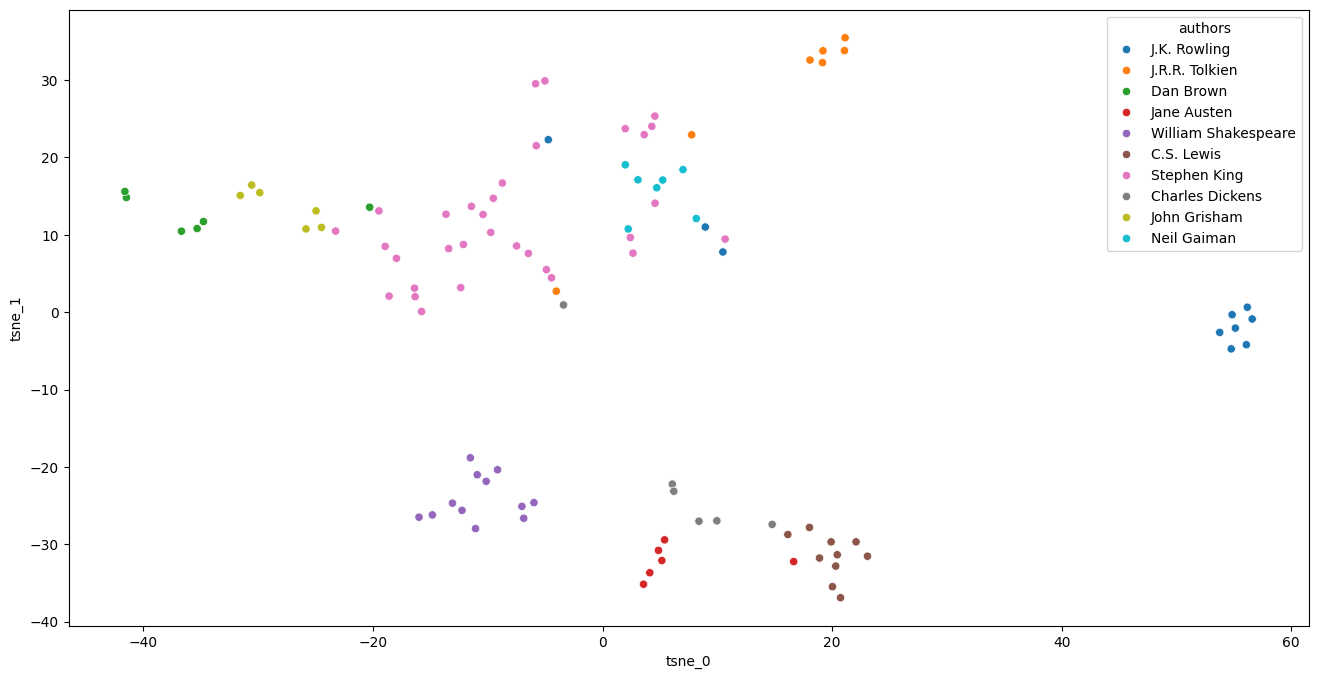

In [134]:
plt.figure(figsize = (16, 8))
sns.scatterplot(
    df_books_tsne_emb, x = 'tsne_0', y = 'tsne_1', hue = 'authors'
)
plt.show()

## Step 1-6, Optional

**book_coef** 데이터프레임을 다음과 같은 형식의 탭 구분 파일로 저장합니다.

**book_coef.tsv**
<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:20px">

|$b_0$|$b_1$|$b_2$|...|$b_9$|
|-----|-----|-----|---|----|
|b(1, 0)|b(1, 1)|b(1, 2)|...|b(1, 9)|
|b(2, 0)|b(2, 1)|b(2, 2)|...|b(2, 9)|
|...|...|...|...|...|
|b(2355, 0)|b(2355, 1)|b(2355, 2)|...|b(2355, 9)|
</div>

Python 함수 가이드
```
pd.DataFrame.to_csv
sep='\t', header=None, index=None

```

**books** 데이터프레임을 아래와 같은 형식으로 재구성하여, 탭 구분 파일로 저장합니다.

**books.tsv**
<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:20px">

|authors|original_title|pub_year|genre|children|
|-------|--------------|-----|--------|--------|
|Suzanne Collins|The Hunger Games|2008.0|Adventure|0|
|J.K. Rowling|Harry Potter and the Philosopher's Stone|1997.0|Fantasy|1|
|...|...|...|...|...|
|George Eliot|Silas Marner: The Weaver of Raveloe|1861.0|Drama|0|
</div>

original_title의 결측치는 'Unknown'으로 바꾸어 저장합니다. (**books**의 내용은 바꾸지 않습니다.)

Python 함수 가이드
```
pd.DataFrame.to_csv
sep='\t', index=None

```


[Embedding Projector](https://projector.tensorflow.org/)에 접속합니다.

우측의 회색 바탕 Load 버튼을 클릭하면

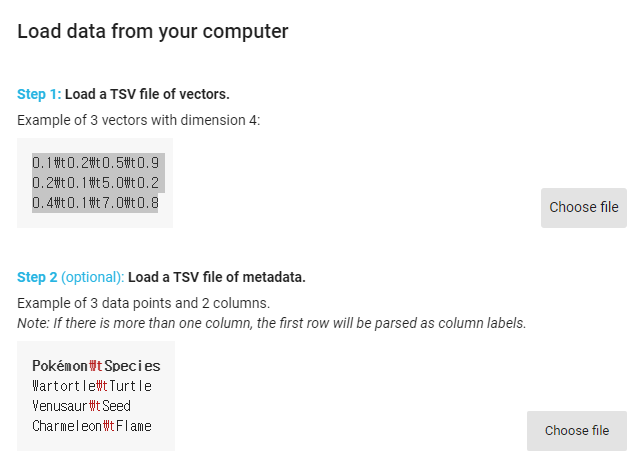

위와 같은 창이 나타납니다.

Step 1에는 book_coef.tsv를,

Step 2에는 books.tsv를 전달합니다.

# 문제 2

**book_coef**의 각 변수와 children의 연관성, 그리고 **book_coef**의 각 변수와 genre의 연관성을 가설 검정으로 확인합니다.

book_coef의 각 변수를 범주형 변수(children, genre)로 구분했을 때,

모평균이 같다면 연관성이 없는 것으로,

모평균이 다르다면 연관성이 있는 것으로 판단합니다.

## Step 2-1

**book_coef**와 **books**를 book_id를 기준으로 inner 방식으로 결합하여 **book_ind**를 만듭니다.

**book_ind**의 변수 b0, b1, ..., b9를 통틀어 **B2**라고 정의합니다.

## Step 2-2

**book_ind**에서 B2와 children 변수의 연관성을 다음 절차에 따라 파악합니다.

B2 중에서 children과 연관성이 있는 변수의 수 **A**를 구합니다.

**검정 절차**

B2의 각 관측값을 children으로 구분하여, 변수별로 두 개의 표본 집단을 만듭니다.

구분한 각각의 표본에 대해 Kolmogorov-Smirnov 검정을 사용하여 정규분포를 따르는지 판단합니다. (**유의 수준: 1%**)

B2 변수들 중에서 children에 따른 두 모집단이 Kolmogorov-Smirnov 검정 결과 모두 정규분포를 따른다고 할 수 있다면,

독립표본 t 검정의 결과를 이용하여 연관성을 파악합니다. (**유의 수준 5%**)

독립표본 t 검정 시에는 Bartlett 검정으로 등분산 여부(**유의 수준 5%**)를 파악하여 검정 방법을 정합니다.

그렇지 않다면

Mann-Whitney U 검정을 사용하여 파악합니다. (**유의 수준 5%**)


Python 함수 가이드
```
from scipy.stats import kstest, ttest_ind, mannwhitneyu, norm 활용

문제에서 제시한 요건 외에는 기본 설정을 사용합니다.

```

## Step 2-3

**book_ind**에서 출현 빈도가 40회 이상인 genre에 해당하는 행만 남겨 **book_ind2**를 만듭니다.

## Step 2-4

**book_ind2**에서 B2 변수들과 genre의 연관성을 다음 검정 절차를 통해 확인합니다.

B2 중에서 genre와 연관성이 있는 변수의 수 **B**를 구합니다.

**검정 절차**

B2의 변수가 genre별 모집단에서 모두 정규분포를 따르고 서로 분산이 같다면, 일원분산분석(one-way ANOVA)을 통해

genre와의 연관성을 파악합니다.

정규성 검정은 Shapiro-Wilk 검정으로 파악하고(**유의 수준 5%**), 등분산 여부는 Bartlett 검정으로 파악합니다. (**유의 수준 5%**)

그렇지 않다면, Kruskal-Wallis 검정을 통해 연관성을 파악합니다. (**유의 수준 5%**)


Python 함수 가이드
```
from scipy.stats import shapiro, f_oneway, kruskal 활용

문제에서 제시한 요건 외에는 기본 설정을 사용합니다.

```

# 문제 3

**user_coef**가 사용자의 성향을 반영하고 있는지, **user_coef**를 입력으로 하는 예측 모델을 만들어 확인합니다.

사용자의 유형은 **ratings**에 **books**의 genre 정보를 결합하여 사용자별 genre 평가 내역을 만들고, 이를 군집 분석하여 얻습니다.

그다음 **user_coef**의 u0, u1, ..., u9 변수만으로 사용자 유형을 분류하는 모델을 만들어 성능을 측정합니다.

이 분류 모델의 성능을 통해 **user_coef**가 사용자의 특성을 얼마나 잘 나타내는지 확인합니다.


## Step 3-1

**books**에서 주요 장르에 해당하는

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">
    
Adventure, Comedy, Biography, Fantasy, Horror, Mystery, Romance, Sci-Fi, Thriller, Drama

</div>

에 해당하는 행을 선택하고, book_id와 genre 열만으로 **books2**를 만듭니다.

**ratings**와 **books2**를 book_id를 기준으로 inner 방식으로 결합하여 **ratings2**를 구성합니다.

## Step 3-2

**ratings2**에서 사용자(user_id)별로 평점을 남긴 장르의 비율을 구하여 아래와 같은 데이터프레임으로 만들고,  

user_id를 기준으로 오름차순 정렬한 데이터프레임을 **user_ratings**라고 합니다.

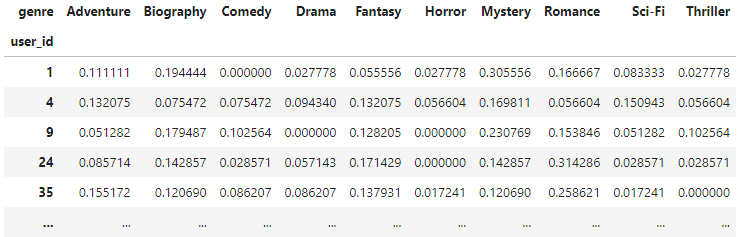

※ 위 결과는 예시이며 실제 결과와는 무관합니다.

## Step 3-3

**user_ratings**으로 K-Means 군집화를 합니다.

군집의 수를 3에서 7까지 바꾸어 가며 군집화를 수행하고, 각각의 실루엣 스코어(Silhouette Score)를 구합니다.

이 중 실루엣 스코어가 가장 좋은 군집 수의 K-Means 모델을 선택합니다.

입력 변수: Adventure, Biography, Comedy, Drama, Fantasy, Horror, Mystery, Romance, Sci-Fi, Thriller

모델 평가 지표:

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">

 $s_i = \frac{(b_i - a_i)}{max(a_i, b_i)}$
  
 $a_i$: i번째 샘플과 같은 클러스터에 속한 다른 샘플들과의 거리의 평균,

 $b_i$: i번째 샘플이 속하지 않은 클러스터 중 가장 인접한 클러스터의 샘플들과의 거리의 평균
  
 $Silhouette\_Score = \frac{1}{N}\sum_{i=1}^{N}s_i$

</div>

Python 함수 가이드
```
from sklearn.cluster import KMeans
    init='random', n_init=100, random_state=123으로 설정하여 사용합니다.

from sklearn.metrics import silhouette_score

문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```

## Step 3-4

**Step 3-3**에서 선택한 K-Means 모델과 **user_ratings**를 통해 user_id별 소속 군집을 구합니다.

**user_coef**의 각 user_id에 대응하는 소속 군집을 target이라는 파생변수로 추가하여

새로운 **user_coef2** 데이터프레임을 만듭니다.

## Step 3-5

**user_coef2**의 u0, u1, ..., u9 변수를 표준화하여 같은 변수명으로 **user_coef2**에 저장합니다.

**user_coef2**는 user_id를 기준으로 오름차순 정렬합니다.

**user_coef2**의 변수 u0, u1, ..., u9를 통틀어 **U2**라고 정의합니다.

Python 함수 가이드
```
from sklearn.preprocessing import StandardScaler

문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```

## Step 3-6

**user_coef2**를 사용하여 4가지 모델의 성능을 측정합니다.

검증 방법은 5겹 계층적 교차검증(5-Fold Stratified Cross-Validation)을 수행하여

겹외셋(Out-of-Fold Set)에 대한 성능의 평균을 구하는 방식으로 합니다.

첫 번째 모델(**Step 3-6-1**)의 성능은 **A**,

두 번째 모델(**Step 3-6-2**)의 성능은 **B**,

세 번째 모델(**Step 3-6-3**)의 성능은 **C**,

네 번째 모델(**Step 3-6-4**)의 성능은 **D**로 합니다.

입력변수: **U2**

대상변수: target

성능지표

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">
$Accuracy=\frac{TP + TN}{TP + TN + FP + FN}$


**TP**: True Positive 수, **TN**: True Negative 수, **FP**: False Positive 수, **FN**: False Negative 수
</div>

Python 함수 가이드
```
from sklearn.model_selection import StratifiedKFold를 활용합니다.
random_state=123, shuffle=True

문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```

### Step 3-6-1

**1. Support Vector 분류 모델**
    
**모델 설정**

- kernel function: $K(x, x') = exp(-0.1\cdot||x-x'||^2)$
- C: 0.1
   
Python 함수 가이드
```
from sklearn.svm import SVC
probability=True
문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```

### Step 3-6-2

**2. 로지스틱 회귀 모델**

**모델 설정**
   
- L2 규제 사용
- C: 0.1

Python 함수 가이드
```
from sklearn.linear_model import LogisticRegression
random_state=123, solver = 'lbfgs'
문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```



### Step 3-6-3

**3. 신경망 분류 모델**

**모델 설정**
   
- 최적화 루틴의 최대 반복 횟수: 500회

- 은닉층 수: 2, 첫 번째 은닉층 유닛 수: 8개, 두 번째 은닉층 유닛 수: 4개
    
- 은닉층의 활성화 함수
    
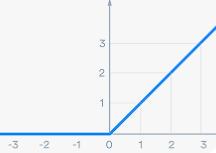
    
Python 함수 가이드
```
from sklearn.neural_network import MLPClassifier
random_state=123
문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```

### Step 3-6-4

**4. Voting 앙상블 분류 모델**

**모델 설정**

- 모델 구성: **Step 3-6-1**, **Step 3-6-2**, **Step 3-6-3**에서 제시한 모델
  
- 부드러운(Soft) Voting 방법 사용

Python 함수 가이드
```
from sklearn.ensemble import VotingClassifier
문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```

# 문제 4

Junior Data Scientist 지희는 프로젝트에서 사용자와 도서의 임베딩이 유효하다는 내용을 타부서에 공유했습니다.

이 발표에 참석한 고객관리 부서는 다음과 같은 과제를 요청했습니다.

> 저희 부서에서는 도서를 어린이와 임산부에게 적합한 정도에 따라 총 3단계로 구분하고 있습니다.
>
> 현재 기준으로는 장르가 Thriller나 Horror이면 Level 2, 어린이용 도서이면 Level 0, 그 외에는 Level 1로 나눕니다.
>
> 장르 정보가 부정확하거나 비어 있는 경우에도 Level을 구분할 수 있는 기능을 개발해 주시기 바랍니다.

이 과제에서는 Level을 분류하는 모델을 만듭니다.


## Step 4-1

**books**와 **book_coef**를 book_id를 기준으로 결합하여 **genre** 셋을 만듭니다.

## Step 4-2

**genre** 셋에서 genre가 Adventure, Comedy, Biography, Fantasy, Horror, Mystery, Romance, Sci-Fi, Thriller, Drama인 행만 뽑아

**level_train** 셋을 만들고, 그 외의 행들로는 **level_test** 셋을 만듭니다.

## Step 4-3

**level_train**에 다음 조건에 맞게 정수형 파생변수 level을 생성합니다.

```
if genre == 'Horror' or genre == 'Thriller' then 2
else if children == 1 then 0
else if children == 0 then 1
```

## Step 4-4

**level_train** 셋을 5조각으로 나누어 교차검증셋을 구성합니다.

5조각으로 나누는 방법은 다음과 같습니다. level별로 book_id 순으로 0에서 시작하여 1씩 증가하는 일련번호를 부여한 뒤,

첫 번째 셋은 일련번호를 5로 나눈 나머지가 0인 행들로 구성합니다.

두 번째 셋은 일련번호를 5로 나눈 나머지가 1인 행들로 구성합니다.

...

다섯 번째 셋은 일련번호를 5로 나눈 나머지가 4인 행들로 구성합니다.


## Step 4-5

XGBoost 모델의 하이퍼파라미터(Hyper-Parameter)를 탐색하여 성능을 최적화하고자 합니다.

하이퍼파라미터는 그리드 탐색(Grid Search)을 사용합니다.

하이퍼파라미터의 대상은 아래와 같습니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">
    
|하이퍼파라미터|탐색 대상 변수|
|--------|-----|
|트리의 최대 깊이|3, 4, 5|
|트리의 수|300, 500, 800|

</div>

**성능 평가 과정**

**Step 4-4**에서 구분한 5개의 셋을 첫 번째 셋부터 다섯 번째 셋까지 차례대로 검증셋(Out-of-Fold Set, 겹외셋)으로 삼아 총 5번의 검증을 다음과 같이 수행합니다.

1. 각각의 검증 단계에서 train셋을 먼저 book_id를 기준으로 정렬합니다.

2. 그다음 train셋에 SMOTE 알고리즘을 적용하여, 대상변수의 빈도수가 가장 높은 클래스를 제외한 나머지 클래스를 가장 높은 빈도수에 맞춰 oversampling합니다.

3. SMOTE로 oversampling한 train셋으로 학습을 하고, 검증셋으로 성능을 평가합니다.

- SMOTE의 샘플링 단계에서 참조하는 주변 샘플의 수는 10개로 설정합니다.

4. 5개 검증셋의 Macro Recall 평균을 Grid Search의 선택 기준으로 합니다.


입력변수: b0, b1, ..., b9와 children (XGBoost 모델에 전달할 때 변수의 순서를 맞춰서 전달합니다.)

대상변수: level

성능지표: 5개의 겹외(out-of-fold) 셋의 Macro Recall의 평균

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">

$\text{Macro Recall} = \frac{1}{N} \sum_{i=1}^{N} \text{Recall}_i$

여기서  

- $ N $: 클래스의 총 개수  
- $ \text{Recall}_i = \frac{TP_i}{TP_i + FN_i} $: 클래스 $ i $의 재현율(Recall)  
- $ TP_i $: 클래스 $ i $에 대해 True Positive 개수  
- $ FN_i $: 클래스 $ i $에 대해 False Negative 개수

</div>  


Python 함수 가이드

```
import imblearn.over_sampling
에서 제공하는 기능을 활용합니다. random_state=123으로 설정합니다.

import xgboost as xgb
에서 제공하는 기능을 활용합니다. learning_rate=0.01, random_state=123

문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```

최적 파라미터의 트리 최대 깊이를 **A**, 트리의 수를 **B**, 그때의 성능지표를 **C**라고 합니다.

## Step 4-6

**level_train**에서 대상변수의 빈도수가 가장 높은 클래스를 제외한 나머지 클래스를

가장 높은 빈도수에 맞춰 SMOTE 방법으로 oversampling하여 **level_smote**를 만듭니다.

이때 SMOTE에서 참조할 주변 샘플 수는 **Step 4-5**와 마찬가지로 10개로 합니다.

XGBoost 모델을 아래의 설정으로 **level_smote**을 학습합니다.

**XGBoost 모델의 설정**

- 트리의 최대 깊이: **A**

- 트리의 수: **B**

입력변수: b0, b1, ..., b9와 children (XGBoost 모델에 전달할 때 변수의 순서를 맞춰서 전달합니다.)

대상변수: level


학습한 모델로 **level_test**의 level을 예측하고,

예측 결과가 2인 행의 수를 구하여 **D**로 합니다.

Python 함수 가이드
```
import imblearn.over_sampling
에서 제공하는 기능을 활용합니다. random_state=123으로 설정합니다.

import xgboost as xgb
에서 제공하는 기능을 활용합니다. learning_rate=0.01, random_state=123

문제에서 제시한 요건 외에는 기본 설정을 사용합니다.
```


# 문제 5

Junior Data Scientist 지희는 사용자마다 to_read로 선정한 book_id를 예측하는 로직의 baseline을 구하고자 합니다.

to_read_sample.csv에는 사용자별로 to_read 목록에 담은 도서의 book_id가 들어 있습니다.

사용자(user_id)가 평점을 남긴 도서는 to_read 목록에 포함되어 있지 않습니다.

사용자마다 to_read로 선정할 book_id의 리스트를 만들고,

MAP@4를 사용하여 예측 로직의 성능을 평가해 봅니다.

## Step 5-1

to_read_sample.csv를 불러옵니다. 이 셋을 **to_read_sample** 데이터셋이라고 합니다.

**to_read_sample**의 to_reads 컬럼은 여러 개의 book_id를 '|'으로 구분한 문자열입니다.

문자열로 되어 있는 to_reads를 '|'으로 분리하여 정수형 리스트로 만들고, 같은 변수명(to_reads)에 저장합니다.

## Step 5-2

**to_read_sample**에 있는 사용자(user_id)별 to_read 예상 book_id 리스트를 아래 가이드에 맞춰 만듭니다.

1. **ratings**에서 book_id별 빈도수를 구하여 **rating_book_count** Series를 만듭니다.

2. **rating_book_count**에서 빈도수가 높은 book_id를 우선으로 하여, 사용자(user_id)별로 4개의 book_id로 예상 to_read 리스트를 만듭니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">

※ 주의: 이 때, user_id 별 to_read의 예상 book_id 리스트를 만들 때에는 **ratings**에서 user_id의 평점 내역이 있는 book_id들은 제외합니다.

</div>

위 로직으로 만든 to_read 예상 book_id 리스트와, **to_read_sample**의 user_id별 실제 to_read book_id 리스트를 비교하여

MAP@4를 구해 **A**라고 합니다.


**성능지표**

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">
    
$MAP@4 = \frac{1}{|U|}\sum_{u∈U}\frac{1}{min(m_u,4)}\sum_{k=1}^{min(n_u,4)}Precision_{u}(k) \cdot Correct_{u}(k)$

$U$: user_id 집합

$m_u$: user_id가 $u$인 사용자의 to_read 수

$n_u$: user_id가 $u$인 사용자에 대해 예상한 to_read의 book_id 수

$Precision_u(k)$: user_id가 $u$인 사용자에 대해 예상한 to_reads의 k번째까지의 Precision

$Correct_u(k)$: user_id가 $u$인 사용자에 대해 예상한 to_reads의 k번째 도서가 실제 to_reads에 있으면 1, 없으면 0

Ex) user_id가 9인 사용자가 실제로 to_read로 선택한 book_id가 [230, 895, 112]이고,

$m_9 = 3$,

user_id가 9인 사용자에 대한 예측 book_id 리스트가 [1, 230, 4, 895]라면,

$n_9 = 4$

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">
    
|k|1|2|3|4|
|-|-|-|-|-|
|$Precision_9(k)$|0/1|1/2|1/3|2/4|
|$Correct_9(k)$|0|1|0|1|

</div>
</div>

## Step 5-3

전처리 과정을 분석하면,

사용자별 **user_coef**는 rating이 대상변수인 선형회귀 모델의 계수이고,

**book_coef**는 이 모델의 입력 변수라고 할 수 있습니다.

이를 아래 식으로 표현할 수 있습니다.

$rating(user\_id, book\_id) = b(book\_id, 0) \cdot u(user\_id, 0) + b(book\_id, 1) \cdot u(user\_id, 1) + ... +  b(book\_id, 9) \cdot u(user\_id, 9)$

- **b(book_id, i)**: **book_coef**에서 book_id의 i번째 계수

- **u(user_id, j)**: **user_coef**에서 user_id의 j번째 계수

이 점을 이용하여 **user_coef**에 존재하는 모든 user_id와 **book_coef**에 존재하는 모든 book_id에 대해

아래와 같이 예상 평점 데이터프레임 **ratings_prd**를 만듭니다.

**ratings_prd**의 크기는 4990 x 687입니다.

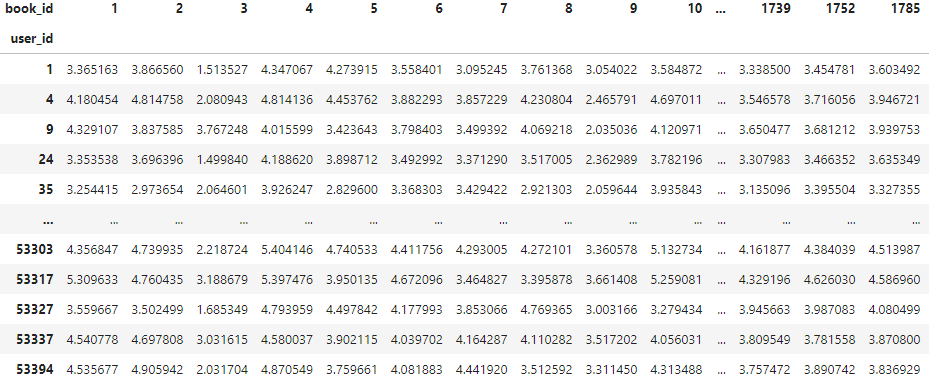

## Step 5-4

**to_read_sample**에 있는 사용자(user_id)별 to_read 예상 book_id 리스트를 아래 가이드에 맞춰 만듭니다.

1. **ratings_prd**에서 예상 rating이 높은 것을 우선으로 하여, 사용자(user_id)별로 4개의 book_id를 포함하는 예상 to_read를 만듭니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">

※ 주의: 이 때, user_id 별 to_read의 예상 book_id 리스트를 만들 때에는 **ratings**에서 user_id의 평점 내역이 있는 book_id들은 제외합니다.

</div>

위 기준으로 만든 to_read 예상 book_id 리스트와, **to_read_sample**의 user_id별 실제 to_read book_id 리스트를 비교하여

MAP@4를 구해 **B**라고 합니다.

# 문제 6

이 업무를 맡은 지희는 평점(rating)이 낮더라도 사용자가 읽은 책이라면 관심을 보인 것이라고 생각했습니다.

즉, 평점이 아무리 낮아도 읽지 않은 책보다는 사용자의 관심이 있다는 것입니다.

또한 평균 평점이 높은 책 중 상당수는 평가 수가 적은 책이라는 점에서,

평점에는 치우침 현상이 있어 평점만으로 선호도를 예측하기에는 부족하다고 생각했습니다.

to_read를 예측하기 위한 다른 모델을 Senior Data Scientist 재윤과 논의한 끝에, 다음 모델을 생각했습니다.

> 평가를 한 책은 '읽음', 평가를 하지 않은 책은 '읽지 않음'으로 하여
>
> 책을 읽었는지 여부(읽음 / 읽지 않음)로 문제를 재정의해 보자.

이렇게 하면 평점을 남기지 않은 경우도 데이터로 활용할 수 있어, 평점만으로는 드러나지 않는 특성을 반영할 수 있습니다.

이를 위해 전처리 단계에서 특성을 추출한 방법을 다음과 같이 응용합니다.


1. 아래와 같이 각각의 사용자와 도서를 벡터로 나타내어 행렬로 나타냅니다.

사용자별로 실수 벡터를 모아 (사용자수×n) 행렬로 나타냅니다. 각각의 벡터는 user_id를 통해 접근합니다. (**user_read_coef**)

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">

|user_id|$u_0$|$u_1$|$u_2$|...|$u_n$|
|-------|--|--|--|---|--|
|1|0.251|0.1|0.03|...|0.15|
|4|0.08|0.15|0.01|...|0.8|
|...|...|...|...|...|...|
|53394|0.01|0.81|0.12|...|0.92|

</div>

※ 위 수치는 예시이며 실제 값과는 무관합니다.

💡Hint: user_id를 인덱스로 한 pd.DataFrame 구조를 사용하는 것을 권장합니다.


도서별로 실수 벡터를 모아 (도서의 수×n) 행렬로 나타냅니다. 각각의 벡터는 book_id를 통해 접근합니다. (**book_read_coef**)

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">

|book_id|$b_0$|$b_1$|$b_2$|...|$b_n$|
|-------|--|--|--|---|--|
|1|0.1|0.128|0.5|...|0.1|
|2|0.07|0.18|0.25|...|0.02|
|...|...|...|...|...|...|
|2355|0.08|0.11|0.02|...|0.05|

</div>

※ 위 수치는 예시이며 실제 값과는 무관합니다.

💡Hint: book_id를 인덱스로 한 pd.DataFrame 구조를 사용하는 것을 권장합니다.

사용자 user_id가 도서 book_id를 읽을 Logit을 아래와 같이 정의합니다.

$Logit(user\_id, book\_id) = b(book\_id, 0) \cdot u(user\_id, 0) + b(book\_id, 1) \cdot u(user\_id, 1) + ... +  b(book\_id, n-1) \cdot u(user\_id, n-1)$

- b(book_id, i): **book_read_coef**에서 book_id의 i번째 계수

- u(user_id, j): **user_read_coef**에서 user_id의 j번째 계수

$\sigma(x)=\frac{1}{1 + e^{-x}}$

$\hat{y}(user\_id, book\_id) = \sigma(Logit(user\_id, book\_id))$


위와 같이 절편항을 제외한 로지스틱 회귀모델의 형태를 응용한 모델을 구상하여 **book_read_coef**, **user_read_coef**를 구합니다.

## Step 6-1

**ratings**를 기반으로, 인덱스(행)는 user_id, 컬럼(열)은 book_id이고,

값은 해당 user_id가 해당 book_id에 평점을 남겼으면 1, 남기지 않았으면 0인

**read** 데이터프레임으로 재구성합니다.

행은 user_id에 대해서 오름차순으로, 열은 book_id에 대해서 오름차순으로 정렬합니다.

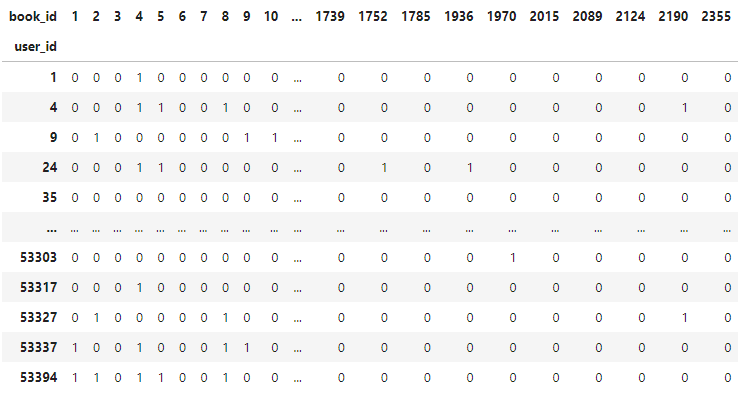


Python 함수 가이드
```
pd.crosstab
```

## Step 6-2

n = 64로 설정합니다.

**book_read_coef**와 **user_read_coef**를 아래 루틴으로 초기화합니다.

**Step 6-1**에서 만든 **read**의 변수명을 df_read로 했을 때를 기준으로 만든 루틴입니다.

Python: book_read_coef, user_read_coef 초기화 루틴
```python
np.random.seed(123)
n = 64
df_user_read_coef = pd.DataFrame(
    np.random.random(size=(df_read.shape[0], n)) * 1 / (n ** 0.5), index=df_read.index
)
df_book_read_coef = pd.DataFrame(
    np.random.random(size=(df_read.shape[1], n)) * 1 / (n ** 0.5), index=df_read.columns
)
```

## Step 6-3

행은 사용자(user_id), 열은 도서(book_id)이고 요소는 $Logit(user\_id, book\_id)$인 행렬을 $L$이라고 합니다.

행렬 $L$을 **read**와 동일한 형태로, 아래에서 제시한 방법으로 구합니다.

**read**의 행에 해당하는 user_id 벡터를 **user_read_coef**에서 가져와, user_id의 순서에 맞게 행렬 $U$를 구성합니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">

$U: N_u × n$ 행렬

</div>

**read**의 열에 해당하는 book_id 벡터를 **book_read_coef**에서 가져와, book_id의 순서에 맞게 행렬 $B$를 구성합니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">

$B: N_b × n$ 행렬

</div>

이렇게 구성하면 문제 6 서두에서 제시한 모델을 다음과 같이 $U$와 $B$의 행렬 곱으로 나타낼 수 있습니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">

$L = U×B^T$

- $B^T$ 는 B의 전치행렬
- $L$: $N_u × N_b$ 행렬
- $N_u$: 사용자수
- $N_b$: 도서수

</div>

행은 사용자(user_id), 열은 도서(book_id)이고 요소는 $\hat{y}(user\_id, book\_id)$인 행렬을 $\hat{Y}$이라고 하면,

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">

$\hat{Y} = \sigma(L)$ , $\sigma(x)=\frac{1}{1 + e^{-x}}$ 가 됩니다.

</div>

손실을 아래와 같이 정의합니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">
    
$Loss(Y, \hat{Y}) = \frac{1}{N_u×N_b}\sum{\left( -y\cdot log(\hat{y}) - (1-y)\cdot log(1-\hat{y}) \right)} $

</div>

이때 $Y$는 **read**입니다.

💡Hint: 초기 **user_read_coef**, **book_read_coef**로 $Loss(Y, \hat{Y})$를 구하면 0.805입니다. (소수점 넷째 자리에서 반올림하여 셋째 자리까지 표시)

**Python 함수 가이드**

```
from numpy import dot
from scipy.special import expit, xlogy
```


## Step 6-4

지희는 $U$와 $B$를 구하는 방법을 찾기 위해 오랜 시간 고민한 끝에,

신경망 학습의 역전파(Back-Propagation) 알고리즘을 떠올립니다.

아래 과정을 거쳐 $ \frac{dLoss(Y, \hat{Y})}{dU} $, $ \frac{dLoss(Y, \hat{Y})}{dB} $를 유도합니다. (경사도 계산에서 편의상 $\frac{1}{N_u×N_b}$ 제외합니다.)

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">

$\frac{dLoss(Y, \hat{Y})}{d\hat{Y}} = \frac{\hat{Y} - Y}{\hat{Y}(1 - \hat{Y})}$,

$\frac{d\hat{Y}}{dL} = \hat{Y}(1-\hat{Y})$,

$\frac{dLoss(Y, \hat{Y})}{dL} = \hat{Y} - Y$

$\frac{dLoss(Y, \hat{Y})}{dU} = \frac{dLoss(Y, \hat{Y})}{dL} × \frac{dL}{dU} = (\hat{Y} - Y)×B$

$\frac{dLoss(Y, \hat{Y})}{dB} = (\hat{Y} - Y)^T×U$

</div>

이를 이용하여 아래와 같은 경사하강법을 이용하여,

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">

$ΔU = \frac{dLoss(Y, \hat{Y})}{dU}$

$ΔB = \frac{dLoss(Y, \hat{Y})}{dB}$

$U ← U - \lambda × ΔU$

$B ← B - \lambda × ΔB$

</div>

$U$와 $B$를 구합니다.

학습률 $\lambda = 0.001$로 설정하여 $U$와 $B$의 업데이트를 1000회 반복합니다.


💡Hint

첫 번째 $U$, $B$ 업데이트 후 $Loss(Y, \hat{Y})$는 0.599입니다. (넷째 자리에서 반올림하여 셋째 자리까지 표시)

1000회 반복 후 $Loss(Y, \hat{Y})$는 0.111입니다. (넷째 자리에서 반올림하여 셋째 자리까지 표시)

Python 함수 가이드
```
from numpy import dot

from scipy.special import expit, xlogy
```

## Step 6-5

**to_read_sample**에 있는 사용자(user_id)별 to_read 예상 book_id 리스트를 아래 가이드에 맞춰 만듭니다.

1. **to_read_sample**에 있는 각각의 user_id와 **book_read_coef**의 각 book_id에 대해, **user_read_coef**와 **book_read_coef**로 Logit을 구해 **logit** 셋을 만듭니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:0px">

$Logit(user\_id, book\_id) = b(book\_id, 0) \cdot u(user\_id, 0) + b(book\_id, 1) \cdot u(user\_id, 1) + ... +  b(book\_id, n-1) \cdot u(user\_id, n-1)$

- b(book_id, i): **book_read_coef**에서 book_id의 i번째 계수

- u(user_id, j): **user_read_coef**에서 user_id의 j번째 계수

</div>

2. **logit**은 사용자(user_id)별로 각 book_id를 읽을 가능성을 나타냅니다. 이를 이용해 사용자(user_id)별로 가능성이 높은 4개의 book_id를 포함하는 예상 to_read를 만듭니다.

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">

※ 주의: 이 때, user_id별 to_read의 예상 book_id 리스트를 만들 때에는 **ratings**에서 user_id의 평점 내역이 있는 book_id들은 제외합니다.

</div>

위 로직으로 만든 to_read 예상 book_id 리스트와, **to_read_sample**의 user_id별 실제 to_read book_id 리스트를 비교하여

MAP@4를 구해 **A**라고 합니다.

# Kaggle형 문제

주어진 데이터셋을 최대한 활용하여,

**to_read_kaggle**에 있는 사용자별로 to_read 목록에 담을 만한 book_id 4개를 예측하여 아래와 같은 파일을 만듭니다.

**to_read_kaggle**의 user_id는 모두 **ratings**에 등장하는 user_id입니다.

실제 user_id별 to_reads의 book_id 리스트에는 해당 user_id가 **ratings**에서 평점을 남긴 book_id는 포함되지 않습니다.


**출력 파일**

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">

4개의 book_id는 '|'로 구분한 문자열로 표시합니다.

제출 파일 형식: csv 파일

user_id, to_read_books

9, 1|2|3|4

35, 5|6|7|8

....

</div>


**성능지표**

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">
    
$MAP@4 = \frac{1}{|U|}\sum_{u∈U}\frac{1}{min(m_u,4)}\sum_{k=1}^{min(n_u,4)}Precision_{u}(k) \cdot Correct_{u}(k)$

$U$: user_id 집합

$m_u$: user_id가 $u$인 사용자의 to_read 수

$n_u$: user_id가 $u$인 사용자에 대해 예상한 to_read의 book_id 수

$Precision_u(k)$: user_id가 $u$인 사용자에 대해 예상한 to_reads의 k번째까지의 Precision

$Correct_u(k)$: user_id가 $u$인 사용자에 대해 예상한 to_reads의 k번째 도서가 실제 to_reads에 있으면 1, 없으면 0

Ex) user_id가 9인 사용자가 실제로 to_read로 선택한 book_id가 [230, 895, 112]이고,

$m_9 = 3$,

user_id가 9인 사용자에 대한 예측 book_id 리스트가 [1, 230, 4, 895]라면,

$n_9 = 4$

<div style="text-align:left; display:inline-block; width:auto; padding-left:20px; padding-bottom:10px">
    
|k|1|2|3|4|
|-|-|-|-|-|
|$Precision_9(k)$|0/1|1/2|1/3|2/4|
|$Correct_9(k)$|0|1|0|1|

</div>
</div>